In [2]:
import numpy as np
import tvm
from tvm import relax
from tvm.script import relax as R
from tvm.script import tir as T


[21:03:05] /workspace/tvm/src/target/llvm/llvm_instance.cc:219: Error: Using LLVM 19.1.7 with `-mcpu=apple-m1` is not valid in `-mtriple=arm64-apple-macos`, using default `-mcpu=generic`
[21:03:05] /workspace/tvm/src/target/llvm/llvm_instance.cc:219: Error: Using LLVM 19.1.7 with `-mcpu=apple-m1` is not valid in `-mtriple=arm64-apple-macos`, using default `-mcpu=generic`
[21:03:05] /workspace/tvm/src/target/llvm/llvm_instance.cc:219: Error: Using LLVM 19.1.7 with `-mcpu=apple-m2` is not valid in `-mtriple=arm64-apple-macos`, using default `-mcpu=generic`
[21:03:05] /workspace/tvm/src/target/llvm/llvm_instance.cc:219: Error: Using LLVM 19.1.7 with `-mcpu=apple-m2` is not valid in `-mtriple=arm64-apple-macos`, using default `-mcpu=generic`
[21:03:05] /workspace/tvm/src/target/llvm/llvm_instance.cc:219: Error: Using LLVM 19.1.7 with `-mcpu=apple-m1` is not valid in `-mtriple=arm64-apple-macos`, using default `-mcpu=generic`
[21:03:05] /workspace/tvm/src/target/llvm/llvm_instance.cc:219: E

In [3]:
import torch
import torchvision

test_data = torchvision.datasets.FashionMNIST(
    root="data", train=False, download=True, transform=torchvision.transforms.ToTensor()
)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=1, shuffle=True)
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

img, label = next(iter(test_loader))
img = img.reshape(1, 28, 28).numpy()

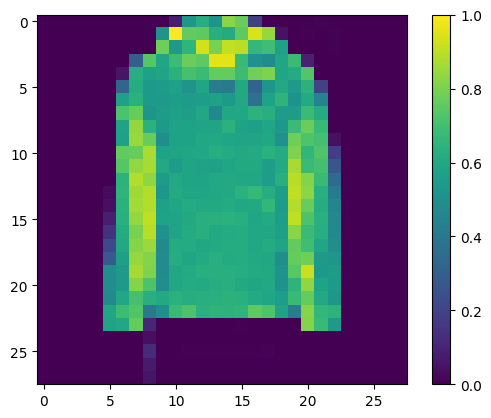

Class: Coat


In [4]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(img[0])
plt.colorbar()
plt.grid(False)
plt.show()
print("Class:", class_names[label[0]])

In [5]:
def numpy_mlp(data, w0, b0, w1, b1):
    lv0 = data @ w0.T + b0
    lv1 = np.maximum(lv0, 0)
    lv2 = lv1 @ w1.T + b1
    return lv2


In [6]:
!wget https://github.com/mlc-ai/web-data/raw/main/models/fasionmnist_mlp_params.pkl

--2026-04-17 21:03:08--  https://github.com/mlc-ai/web-data/raw/main/models/fasionmnist_mlp_params.pkl
Loaded CA certificate '/etc/ssl/certs/ca-certificates.crt'
Resolving github.com (github.com)... 140.82.121.3
Connecting to github.com (github.com)|140.82.121.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/mlc-ai/web-data/main/models/fasionmnist_mlp_params.pkl [following]
--2026-04-17 21:03:09--  https://raw.githubusercontent.com/mlc-ai/web-data/main/models/fasionmnist_mlp_params.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 407396 (398K) [application/octet-stream]
Saving to: 'fasionmnist_mlp_params.pkl.1'

fasionmnist_mlp_par 100%[===================>] 397.85K  2.01MB/s    in 0.2s    

In [7]:
import pickle as pkl

mlp_params = pkl.load(open("fasionmnist_mlp_params.pkl", "rb"))
res = numpy_mlp(
    img.reshape(1, 784),
    mlp_params["w0"],
    mlp_params["b0"],
    mlp_params["w1"],
    mlp_params["b1"],
)
print(res)
pred_kind = res.argmax(axis=1)
print(pred_kind)
print("NumPy-MLP Prediction:", class_names[pred_kind[0]])


[[-28.821772  -18.45548     6.276931  -11.511452   13.878548  -14.563345
  -13.5834055 -28.534035  -12.861148  -49.375652 ]]
[4]
NumPy-MLP Prediction: Coat


In [8]:
def lnumpy_linear0(X: np.ndarray, W: np.ndarray, B: np.ndarray, Z: np.ndarray):
    Y = np.empty((1, 128), dtype="float32")
    for i in range(1):
        for j in range(128):
            for k in range(784):
                if k == 0:
                    Y[i, j] = 0
                Y[i, j] = Y[i, j] + X[i, k] * W[j, k]

    for i in range(1):
        for j in range(128):
            Z[i, j] = Y[i, j] + B[j]


def lnumpy_relu0(X: np.ndarray, Y: np.ndarray):
    for i in range(1):
        for j in range(128):
            Y[i, j] = np.maximum(X[i, j], 0)


def lnumpy_linear1(X: np.ndarray, W: np.ndarray, B: np.ndarray, Z: np.ndarray):
    Y = np.empty((1, 10), dtype="float32")
    for i in range(1):
        for j in range(10):
            for k in range(128):
                if k == 0:
                    Y[i, j] = 0
                Y[i, j] = Y[i, j] + X[i, k] * W[j, k]

    for i in range(1):
        for j in range(10):
            Z[i, j] = Y[i, j] + B[j]


def lnumpy_mlp(data, w0, b0, w1, b1):
    lv0 = np.empty((1, 128), dtype="float32")
    lnumpy_linear0(data, w0, b0, lv0)

    lv1 = np.empty((1, 128), dtype="float32")
    lnumpy_relu0(lv0, lv1)

    out = np.empty((1, 10), dtype="float32")
    lnumpy_linear1(lv1, w1, b1, out)
    return out


result = lnumpy_mlp(
    img.reshape(1, 784),
    mlp_params["w0"],
    mlp_params["b0"],
    mlp_params["w1"],
    mlp_params["b1"],
)

pred_kind = result.argmax(axis=1)
print("Low-level Numpy MLP Prediction:", class_names[pred_kind[0]])

Low-level Numpy MLP Prediction: Coat


In [16]:
@tvm.script.ir_module
class MyModule:
    @T.prim_func
    def relu0(x: T.handle, y: T.handle):
        n = T.int64()
        X = T.match_buffer(x, (1, n), "float32")
        Y = T.match_buffer(y, (1, n), "float32")
        for i, j in T.grid(1, n):
            with T.sblock("Y"):
                vi, vj = T.axis.remap("SS", [i, j])
                Y[vi, vj] = T.max(X[vi, vj], T.float32(0))

    @T.prim_func
    def linear0(x: T.handle, w: T.handle, b: T.handle, z: T.handle):
        m, n, k = T.int64(), T.int64(), T.int64()
        X = T.match_buffer(x, (1, m), "float32")
        W = T.match_buffer(w, (n, m), "float32")
        B = T.match_buffer(b, (n,), "float32")
        Z = T.match_buffer(z, (1, n), "float32")
        Y = T.alloc_buffer((1, n), "float32")
        for i, j, k in T.grid(1, n, m):
            with T.sblock("Y"):
                vi, vj, vk = T.axis.remap("SSR", [i, j, k])
                with T.init():
                    Y[vi, vj] = T.float32(0)
                Y[vi, vj] = Y[vi, vj] + X[vi, vk] * W[vj, vk]
        for i, j in T.grid(1, n):
            with T.sblock("Z"):
                vi, vj = T.axis.remap("SS", [i, j])
                Z[vi, vj] = Y[vi, vj] + B[vj]

    @R.function
    def main(
        x: R.Tensor((1, "m"), "float32"),
        w0: R.Tensor(("n", "m"), "float32"),
        b0: R.Tensor(("n",), "float32"),
        w1: R.Tensor(("k", "n"), "float32"),
        b1: R.Tensor(("k",), "float32"),
    ):
        m, n, k = T.int64(), T.int64(), T.int64()
        with R.dataflow():
            lv0 = R.call_dps_packed("linear0", (x, w0, b0), R.Tensor((1, n), "float32"))
            lv1 = R.call_dps_packed("relu0", (lv0,), R.Tensor((1, n), "float32"))
            out = R.call_dps_packed(
                "linear0", (lv1, w1, b1), R.Tensor((1, k), "float32")
            )
            R.output(out)
        return out


In [17]:
def lnumpy_call_dps_packed(prim_func, inputs, shape, dtype):
    res = np.empty(shape, dtype=dtype)
    prim_func(*inputs, res)
    return res

In [18]:
def lnumpy_mlp_with_call_dps_packed(data, w0, b0, w1, b1):
    lv0 = lnumpy_call_dps_packed(
        lnumpy_linear0, (data, w0, b0), (1, 128), dtype="float32"
    )
    lv1 = lnumpy_call_dps_packed(lnumpy_relu0, (lv0,), (1, 128), dtype="float32")
    out = lnumpy_call_dps_packed(
        lnumpy_linear1, (lv1, w1, b1), (1, 10), dtype="float32"
    )
    return out


result = lnumpy_mlp_with_call_dps_packed(
    img.reshape(1, 784),
    mlp_params["w0"],
    mlp_params["b0"],
    mlp_params["w1"],
    mlp_params["b1"],
)

pred_kind = np.argmax(result, axis=1)
print("Low-level Numpy with CallTIR Prediction:", class_names[pred_kind[0]])


Low-level Numpy with CallTIR Prediction: Coat


In [19]:
target = tvm.target.Target("llvm", host="llvm")
ex = tvm.compile(MyModule, target)
type(ex)

tvm.relax.vm_build.VMExecutable

In [20]:
vm = relax.VirtualMachine(ex, tvm.cpu())

In [21]:
data_nd = tvm.runtime.tensor(img.reshape(1, 784))
nd_params = {k: tvm.runtime.tensor(v) for k, v in mlp_params.items()}

In [22]:
nd_res = vm["main"](
    data_nd, nd_params["w0"], nd_params["b0"], nd_params["w1"], nd_params["b1"]
)
print(nd_res)


[[-28.821772 -18.45548    6.276934 -11.511456  13.87855  -14.563343
  -13.583408 -28.534035 -12.861149 -49.375656]]


In [23]:
pred_kind = np.argmax(nd_res.numpy(), axis=1)
print("MyModuleWithParams Prediction:", class_names[pred_kind[0]])

MyModuleWithParams Prediction: Coat
